![NYC Skyline](./graphics/nyc.jpg)

Welcome to New York City, one of the most-visited cities in the world. There are many Airbnb listings in New York City to meet the high demand for temporary lodging for travelers, which can be anywhere between a few nights to many months. In this project, we will take a closer look at the New York Airbnb market by combining data from multiple file types like `.csv`, `.tsv`, and `.xlsx`.

We will work with three files containing data on 2019 Airbnb listings described as follows:

**data/airbnb_price.csv**
This is a CSV file containing data on Airbnb listing prices and locations.
- **`listing_id`**: unique identifier of listing
- **`price`**: nightly listing price in USD
- **`nbhood_full`**: name of borough and neighborhood where listing is located

**data/airbnb_room_type.xlsx**
This is an Excel file containing data on Airbnb listing descriptions and room types.
- **`listing_id`**: unique identifier of listing
- **`description`**: listing description
- **`room_type`**: Airbnb has three types of rooms: shared rooms, private rooms, and entire homes/apartments

**data/airbnb_last_review.tsv**
This is a TSV file containing data on Airbnb host names and review dates.
- **`listing_id`**: unique identifier of listing
- **`host_name`**: name of listing host
- **`last_review`**: date when the listing was last reviewed

## The Scenario

As a consultant working for a real estate company, we have collected Airbnb listing data from various sources to investigate the short-term rental market in New York. We'll analyze this data to provide insights on private rooms to the real estate company.

### First Research Question - *What are the dates of the earliest and most recent reviews?*

We'd also like to see how these reviews are distributed over the roughtly 6 month review period.

In [1]:
# Import necessary packages
import pandas as pd
import numpy as np

# consolidate the data sources for easy access
data_sources = {
    "prices": {"file_path": "./data/airbnb_price.csv",
               "file_type": "text/CSV",
               "delimiter": ","},
    "room_types": {"file_path": "./data/airbnb_room_type.xlsx",
                   "file_type": "binary/Excel",
                   "delimiter": np.nan},  # delimeter not applicable for binary files
    "reviews": {"file_path": "./data/airbnb_last_review.tsv",
                "file_type": "text/TSV",  # tab separated variable
                "delimiter": "\t"}
}

df_reviews = pd.read_csv(data_sources["reviews"]["file_path"], sep=data_sources["reviews"]["delimiter"])
print(f"Total number of reviews: {df_reviews.shape[0]}\n")
print(df_reviews.info(), "\n")
df_reviews.head()

Total number of reviews: 25209

<class 'pandas.DataFrame'>
RangeIndex: 25209 entries, 0 to 25208
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   listing_id   25209 non-null  int64
 1   host_name    25201 non-null  str  
 2   last_review  25209 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.0 MB
None 



,listing_id,host_name,last_review
0,2595,Jennifer,May 21 2019
1,3831,LisaRoxanne,July 05 2019
2,5099,Chris,June 22 2019
3,5178,Shunichi,June 24 2019
4,5238,Ben,June 09 2019


#### First task - convert the `last_review` column to datetime

+ check how dates are encoded
+ convert to datetime so we can find earliest and most recent reviews

In [2]:
# how are dates formatted?
all_dates = df_reviews["last_review"].unique()
all_dates[:10]

<ArrowStringArray>
[    'May 21 2019',    'July 05 2019',    'June 22 2019',    'June 24 2019',
    'June 09 2019',    'June 23 2019',    'June 29 2019',    'June 28 2019',
    'July 01 2019', 'January 01 2019']
Length: 10, dtype: str

Dates appear to be encoded consistently. If they are not, assume that `to_datetime` will not be happy and we can dig into possible issues futher if this is the case.

In [3]:
# should be able to parse to datetime without issues
df_reviews["last_review"] = pd.to_datetime(df_reviews["last_review"])
df_reviews.head()

,listing_id,host_name,last_review
0,2595,Jennifer,2019-05-21
1,3831,LisaRoxanne,2019-07-05
2,5099,Chris,2019-06-22
3,5178,Shunichi,2019-06-24
4,5238,Ben,2019-06-09


In [4]:
earliest_review = df_reviews["last_review"].min()
most_recent_review = df_reviews["last_review"].max()
print(f"earliest_review: {earliest_review}, most recent review: {most_recent_review}")

earliest_review: 2019-01-01 00:00:00, most recent review: 2019-07-09 00:00:00


In [5]:
df_reviews['days_from_first'] = (df_reviews['last_review'] - earliest_review).dt.days.astype('int')
df_reviews['review_month'] = df_reviews['last_review'].dt.month.astype('int')
days_bins = [0, 25, 50, 75, 100, 125, 150, 175]  # init hist used these are major tick labels
df_review_labels = df_reviews.loc[df_reviews['days_from_first'].isin(days_bins), :]
df_review_labels.drop_duplicates(subset=['last_review', 'days_from_first']).sort_values('days_from_first')

,listing_id,host_name,last_review,days_from_first,review_month
14,8025,Lisel,2019-01-01,0,1
48,16326,Dimitri,2019-01-26,25,1
737,484312,Hana,2019-02-20,50,2
992,719329,Silvia,2019-03-17,75,3
1240,900383,Selam,2019-04-11,100,4
214,67299,Adrienne,2019-05-06,125,5
59,18198,Justin,2019-05-31,150,5
93,29683,Uli,2019-06-25,175,6


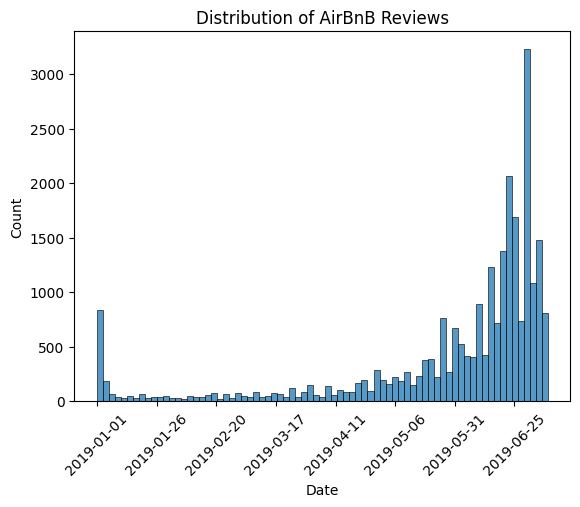

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# dates corresponding to the days_from_first
dates_bins = ['2019-01-01', '2019-01-26', '2019-02-20', '2019-03-17', '2019-04-11', '2019-05-06', '2019-05-31', '2019-06-25']
g = sns.histplot(x='days_from_first', data=df_reviews)
g.set(xlabel='Date', ylabel='Count', title='Distribution of AirBnB Reviews')
plt.xticks(ticks=days_bins, labels=dates_bins, rotation=45)
plt.show()

### More reviews as summer approaches makes sense

### Second Research Question - *How many of the listings are private rooms?*

It would be interesting to see how these listing counts change over time, but to answer the main question...

+ Required data resides in the file `data/airbnb_room_type.xlsx`
+ This spreadsheet has a single sheet: `airbnb_room_type`

We'll need to join this to the reviews data to see the changes over time.

In [7]:
excel_data = pd.ExcelFile(data_sources["room_types"]["file_path"])
print(excel_data.sheet_names, "\n")  # single sheet: 'airbnb_room_type'
df_room_types = excel_data.parse('airbnb_room_type')  # could've use 0 (sheet index), but this is clearer
print(df_room_types.shape, "\n")
df_room_types.info()
df_room_types.head()

['airbnb_room_type'] 

(25209, 3) 

<class 'pandas.DataFrame'>
RangeIndex: 25209 entries, 0 to 25208
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   listing_id   25209 non-null  int64 
 1   description  25199 non-null  object
 2   room_type    25209 non-null  str   
dtypes: int64(1), object(1), str(1)
memory usage: 924.7+ KB


,listing_id,description,room_type
0,2595,Skylit Midtown Castle,Entire home/apt
1,3831,Cozy Entire Floor of Brownstone,Entire home/apt
2,5099,Large Cozy 1 BR Apartment In Midtown East,Entire home/apt
3,5178,Large Furnished Room Near B'way,private room
4,5238,Cute & Cozy Lower East Side 1 bdrm,Entire home/apt


In [8]:
# check the number of room types
print(df_room_types["room_type"].unique())

<ArrowStringArray>
['Entire home/apt',    'private room',    'Private room', 'entire home/apt',
    'PRIVATE ROOM',     'shared room', 'ENTIRE HOME/APT',     'Shared room',
     'SHARED ROOM']
Length: 9, dtype: str


Looks like we 3 different versions of *private room* as well as the other 2 types (*entire home/apt* and *shared room*). We can handle all three by simply converting everything to **lower case**.

In [9]:
df_room_types["room_type"] = df_room_types["room_type"].str.lower()
# check
print(df_room_types["room_type"].unique())

<ArrowStringArray>
['entire home/apt', 'private room', 'shared room']
Length: 3, dtype: str


In [10]:
room_type_counts = df_room_types["room_type"].value_counts()
print(room_type_counts)

room_type
entire home/apt    13266
private room       11356
shared room          587
Name: count, dtype: int64


In [11]:
private_room_count = room_type_counts['private room']
print(f"There are {private_room_count} private room listings")

There are 11356 private room listings


In [12]:
df_rooms_revs = df_room_types.merge(df_reviews, on='listing_id')
df_rooms_revs = df_rooms_revs.loc[:, ['room_type', 'review_month']]
df_rooms_revs

,room_type,review_month
0,entire home/apt,5
1,entire home/apt,7
2,entire home/apt,6
3,private room,6
4,entire home/apt,6
...,...,...
25204,private room,7
25205,private room,7
25206,private room,7
25207,entire home/apt,7


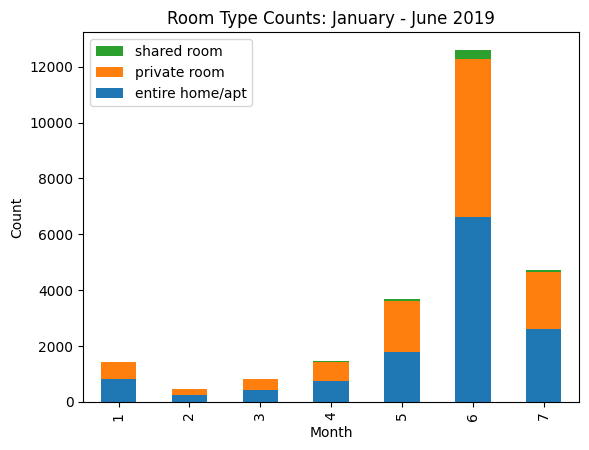

In [13]:
df = df_rooms_revs.groupby(by=['review_month', 'room_type']).size().reset_index(name='count')
df = df.pivot(index='review_month', columns='room_type', values='count')
# df
df.plot(kind='bar', stacked=True,
        title="Room Type Counts: January - July 2019",
        xlabel="Month", ylabel="Count")
plt.legend(reverse=True)
plt.show()

### Third Research Question - *What is the average listing price?*

+ Required data resides in the file `data/airbnb_price.csv`
+ `price` column originally comes in as string (object, as shown below)
  + Values are formatted as `ddd dollars` where `ddd` is the amount, so this needs to be stripped out

In [14]:
df_prices = df_reviews = pd.read_csv(data_sources["prices"]["file_path"], sep=data_sources["prices"]["delimiter"])
print(df_prices.info(), "\n")
df_prices.head()

<class 'pandas.DataFrame'>
RangeIndex: 25209 entries, 0 to 25208
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   listing_id   25209 non-null  int64
 1   price        25209 non-null  str  
 2   nbhood_full  25209 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.4 MB
None 



,listing_id,price,nbhood_full
0,2595,225 dollars,"Manhattan, Midtown"
1,3831,89 dollars,"Brooklyn, Clinton Hill"
2,5099,200 dollars,"Manhattan, Murray Hill"
3,5178,79 dollars,"Manhattan, Hell's Kitchen"
4,5238,150 dollars,"Manhattan, Chinatown"


In [15]:
# strip out the dollars text in the price column and convert to float
df_prices['price'] = df_prices['price'].str.strip(" dollars")
df_prices['price'] = df_prices['price'].astype(float)
df_prices.head()

,listing_id,price,nbhood_full
0,2595,225.0,"Manhattan, Midtown"
1,3831,89.0,"Brooklyn, Clinton Hill"
2,5099,200.0,"Manhattan, Murray Hill"
3,5178,79.0,"Manhattan, Hell's Kitchen"
4,5238,150.0,"Manhattan, Chinatown"


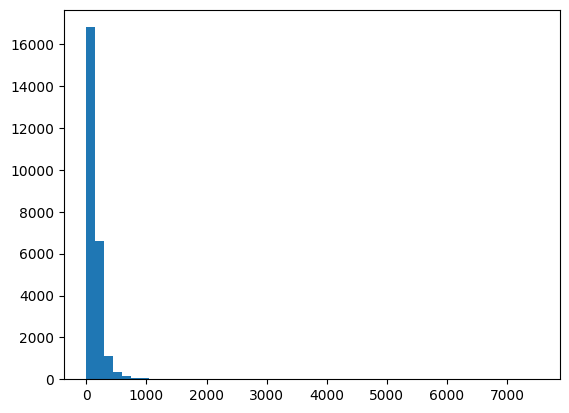

In [20]:
plt.hist(df_prices['price'], bins=50)

plt.show()

In [16]:
average_listing_price = round(df_prices['price'].mean(), 2)
print(f"The average listing price is: ${average_listing_price}")

The average listing price is: $141.78


In [17]:
review_dates = pd.DataFrame({"first_reviewed": [earliest_review],
                              "last_reviewed": [most_recent_review],
                              "nb_private_rooms": [private_room_count],
                              "avg_price": [average_listing_price]})
review_dates

,first_reviewed,last_reviewed,nb_private_rooms,avg_price
0,2019-01-01,2019-07-09,11356,141.78
